In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import BarycentricInterpolator, CubicSpline

# a)

In [17]:
def f1(x):
    return 1 / (1 + 25 * x**2)

In [18]:
n = 12
n_dense = n * 10

In [19]:
x_eq = np.linspace(-1, 1, n)
y_eq = f1(x_eq)
x_dense_eq = np.linspace(-1, 1, n_dense)

In [20]:
j = np.arange(1, n + 1)
theta_cheb = (2 * j - 1) / (2 * n) * np.pi
x_cheb = np.cos(theta_cheb)
y_cheb = f1(x_cheb)

In [21]:
theta_dense = np.linspace(0, np.pi, n_dense)
x_dense_cheb = np.sort(np.cos(theta_dense))

In [22]:
poly_eq = BarycentricInterpolator(x_eq, y_eq)
y_poly_eq = poly_eq(x_dense_eq)

In [23]:
cs_eq = CubicSpline(x_eq, y_eq)
y_cs_eq = cs_eq(x_dense_eq)

In [24]:
poly_cheb = BarycentricInterpolator(x_cheb, y_cheb)
y_poly_cheb = poly_cheb(x_dense_cheb)

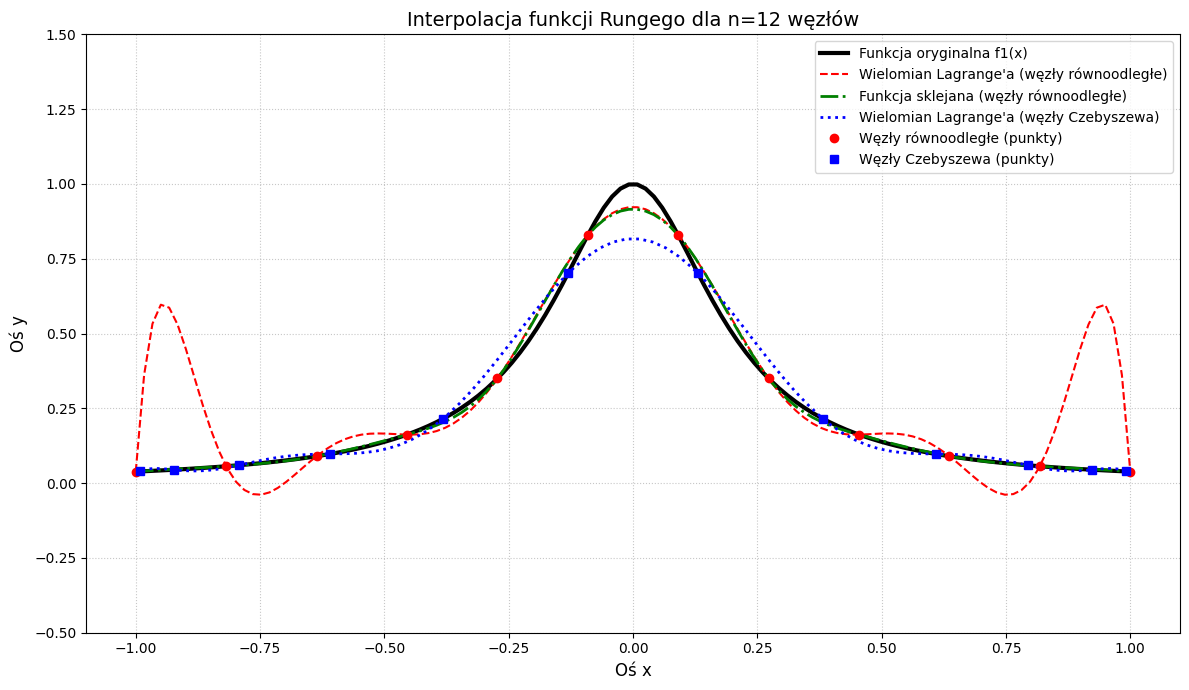

In [25]:
plt.figure(figsize=(12, 7))

plt.plot(x_dense_eq, f1(x_dense_eq), 'k-', linewidth=3, label='Funkcja oryginalna f1(x)')
plt.plot(x_dense_eq, y_poly_eq, 'r--', linewidth=1.5, label='Wielomian Lagrange\'a (węzły równoodległe)')
plt.plot(x_dense_eq, y_cs_eq, 'g-.', linewidth=2, label='Funkcja sklejana (węzły równoodległe)')
plt.plot(x_dense_cheb, y_poly_cheb, 'b:', linewidth=2, label='Wielomian Lagrange\'a (węzły Czebyszewa)')

plt.plot(x_eq, y_eq, 'ro', markersize=6, label='Węzły równoodległe (punkty)')
plt.plot(x_cheb, y_cheb, 'bs', markersize=6, label='Węzły Czebyszewa (punkty)')

plt.ylim(-0.5, 1.5)

plt.title(f'Interpolacja funkcji Rungego dla n={n} węzłów', fontsize=14)
plt.xlabel('Oś x', fontsize=12)
plt.ylabel('Oś y', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()